In [33]:
import pandas as pd
import numpy as np
import torch
import os
import glob
import matplotlib.pyplot as plt

In [28]:
path = "/home/mmego/work/repositories/QoL_surrogate/models/data_subsets/"

subset_metrics = {}
frac = [0.1, 0.25, 0.5, 0.75, 0.9, 1.0]

for f in frac:
    model_folder = glob.glob(path + f"gcn_resnet_{f}*")[0]
    print(model_folder)
    checkpoint = torch.load(os.path.join(path, model_folder, "model.pt"), weights_only=False)
    subset_metrics[f] = checkpoint['metrics']['absolute']['overall']


/home/mmego/work/repositories/QoL_surrogate/models/data_subsets/gcn_resnet_0.1_20260814_143346
/home/mmego/work/repositories/QoL_surrogate/models/data_subsets/gcn_resnet_0.25_20260814_151834
/home/mmego/work/repositories/QoL_surrogate/models/data_subsets/gcn_resnet_0.5_20260814_162910
/home/mmego/work/repositories/QoL_surrogate/models/data_subsets/gcn_resnet_0.75_20260814_174013
/home/mmego/work/repositories/QoL_surrogate/models/data_subsets/gcn_resnet_0.9_20260814_190627
/home/mmego/work/repositories/QoL_surrogate/models/data_subsets/gcn_resnet_1.0_20260814_204153


In [59]:
subset_metrics_df = pd.DataFrame.from_dict(subset_metrics, orient='index')

In [64]:
subset_metrics_df.reset_index(names="fraction", inplace=True)

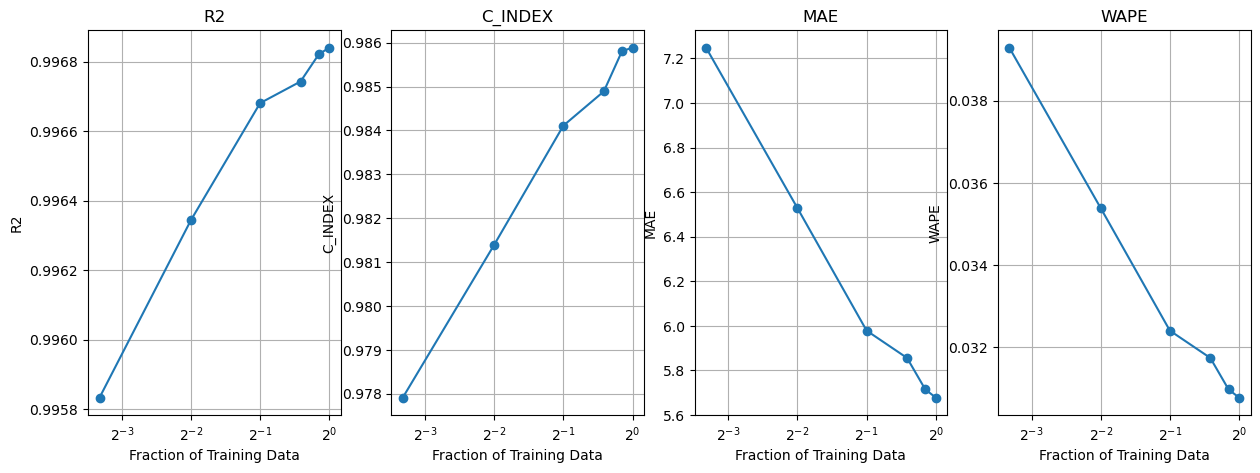

In [65]:
fig, axes = plt.subplots(1, 4, figsize=(15, 5))

for i, metric in enumerate(['r2', 'c_index', 'mae', 'wape']):
    axes[i].plot(subset_metrics_df['fraction'], subset_metrics_df[metric], marker='o')
    axes[i].set_title(metric.upper())
    axes[i].set_xlabel('Fraction of Training Data')
    axes[i].set_ylabel(metric.upper())
    axes[i].grid()

    axes[i].set_xscale("log", base=2)


In [68]:
pct = subset_metrics_df.pct_change()

In [78]:
metrics_pct = pct[['r2', 'mae', 'c_index', 'wape']].dropna().div(pct['fraction'].dropna(), axis=0) * 100
metrics_pct_abs = metrics_pct.abs()

<Axes: >

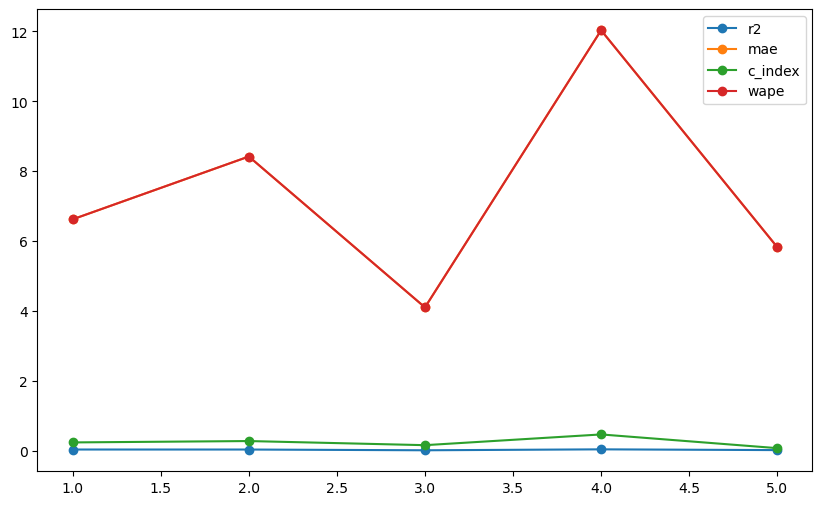

In [80]:
metrics_pct_abs.plot(figsize=(10, 6), marker = 'o')

In [81]:
metrics_pct

,r2,mae,c_index,wape
1,0.034193,-6.623923,0.237475,-6.623924
2,0.033800,-8.421287,0.276607,-8.421290
3,0.012475,-4.102701,0.158614,-4.102719
4,0.039169,-12.034930,0.465838,-12.034893
5,0.017544,-5.827086,0.073306,-5.827153
